Источник данных:
https://www.kaggle.com/datasets/ssssws/chocolate-sales-dataset-2023-2024

Архив с данными:
https://drive.google.com/file/d/18JqlERq5pbZsuQiDgDrW-wESJMxfUq82/view?usp=drive_link

In [1]:
! gdown 18JqlERq5pbZsuQiDgDrW-wESJMxfUq82

Downloading...
From: https://drive.google.com/uc?id=18JqlERq5pbZsuQiDgDrW-wESJMxfUq82
To: /content/chocolate_sales.zip
100% 24.4M/24.4M [00:00<00:00, 64.3MB/s]


In [2]:
! unzip /content/chocolate_sales.zip

Archive:  /content/chocolate_sales.zip
  inflating: calendar.csv            
  inflating: customers.csv           
  inflating: products.csv            
  inflating: sales.csv               
  inflating: stores.csv              


# **Импорт и просмотр данных**

In [4]:
import pandas as pd
from matplotlib import pyplot as plt
import seaborn as sns

In [11]:
df_sales = pd.read_csv('/content/sales.csv', parse_dates = ['order_date'])
df_sales.head()

,order_id,order_date,product_id,store_id,customer_id,quantity,unit_price,discount,revenue,cost,profit
0,0RD00000001,2023-01-07,P0080,S093,C040749,5,14.43,0.15,61.33,42.77,18.56
1,0RD00000002,2023-10-22,P0173,S065,C020161,3,12.01,0.00,36.03,19.06,16.97
2,0RD00000003,2023-05-07,P0115,S078,C048069,2,10.02,0.00,20.04,10.29,9.75
3,0RD00000004,2024-06-23,P0186,S088,C047901,2,14.66,0.10,26.39,16.35,10.04
4,0RD00000005,2024-09-24,P0197,S054,C033950,1,12.34,0.00,12.34,7.94,4.40


In [15]:
df_customers = pd.read_csv('/content/customers.csv', parse_dates = ['join_date'])
df_customers.head()

,customer_id,age,gender,loyalty_member,join_date
0,C000001,40,Male,1,2025-05-21
1,C000002,47,Male,0,2021-12-26
2,C000003,58,Female,1,2022-09-13
3,C000004,25,Female,0,2025-02-27
4,C000005,43,Male,0,2023-08-31


In [7]:
df_products = pd.read_csv('/content/products.csv')
df_products.head()

,product_id,product_name,brand,category,cocoa_percent,weight_g
0,P0001,White Chocolate 80%,Mars,Truffle,80,120
1,P0002,Dark Chocolate 70%,Cadbury,Praline,70,100
2,P0003,Truffle Chocolate 70%,Hershey,Praline,70,120
3,P0004,Milk Chocolate 50%,Mars,Praline,50,80
4,P0005,White Chocolate 70%,Ferrero,White,70,50


In [8]:
df_stores = pd.read_csv('/content/stores.csv')
df_stores.head()

,store_id,store_name,city,country,store_type
0,S001,Chocolate Store 1,New York,Canada,Retail
1,S002,Chocolate Store 2,Melbourne,Canada,Mall
2,S003,Chocolate Store 3,Berlin,France,Mall
3,S004,Chocolate Store 4,Paris,UK,Airport
4,S005,Chocolate Store 5,Sydney,USA,Online


Столбцы представлены в корректных типах: числовые (int64 и float64), даты (datetime64) и текстовые (object).

In [12]:
df_sales.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000000 entries, 0 to 999999
Data columns (total 11 columns):
 #   Column       Non-Null Count    Dtype         
---  ------       --------------    -----         
 0   order_id     1000000 non-null  object        
 1   order_date   1000000 non-null  datetime64[ns]
 2   product_id   1000000 non-null  object        
 3   store_id     1000000 non-null  object        
 4   customer_id  1000000 non-null  object        
 5   quantity     1000000 non-null  int64         
 6   unit_price   1000000 non-null  float64       
 7   discount     1000000 non-null  float64       
 8   revenue      1000000 non-null  float64       
 9   cost         1000000 non-null  float64       
 10  profit       1000000 non-null  float64       
dtypes: datetime64[ns](1), float64(5), int64(1), object(4)
memory usage: 83.9+ MB


In [31]:
df_sales['month_order'] = df_sales.order_date.dt.to_period('M').dt.to_timestamp()

In [16]:
df_customers.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   customer_id     50000 non-null  object        
 1   age             50000 non-null  int64         
 2   gender          50000 non-null  object        
 3   loyalty_member  50000 non-null  int64         
 4   join_date       50000 non-null  datetime64[ns]
dtypes: datetime64[ns](1), int64(2), object(2)
memory usage: 1.9+ MB


In [32]:
df_customers['month_join'] = df_customers.join_date.dt.to_period('M').dt.to_timestamp()

In [17]:
df_products.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   product_id     200 non-null    object
 1   product_name   200 non-null    object
 2   brand          200 non-null    object
 3   category       200 non-null    object
 4   cocoa_percent  200 non-null    int64 
 5   weight_g       200 non-null    int64 
dtypes: int64(2), object(4)
memory usage: 9.5+ KB


In [18]:
df_stores.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   store_id    100 non-null    object
 1   store_name  100 non-null    object
 2   city        100 non-null    object
 3   country     100 non-null    object
 4   store_type  100 non-null    object
dtypes: object(5)
memory usage: 4.0+ KB


# **Подготовка данных и первичный анализ**

В данных не обнаружены пропуски

In [33]:
df_sales.isnull().sum()

,0
order_id,0
order_date,0
product_id,0
store_id,0
customer_id,0
quantity,0
unit_price,0
discount,0
revenue,0
cost,0


In [34]:
df_customers.isnull().sum()

,0
customer_id,0
age,0
gender,0
loyalty_member,0
join_date,0
month_join,0


In [24]:
df_products.isnull().sum()

,0
product_id,0
product_name,0
brand,0
category,0
cocoa_percent,0
weight_g,0


In [25]:
df_stores.isnull().sum()

,0
store_id,0
store_name,0
city,0
country,0
store_type,0


Дубликатов в данных не обнаружено

In [27]:
df_sales.duplicated().sum()

np.int64(0)

In [28]:
df_customers.duplicated().sum()

np.int64(0)

In [29]:
df_products.duplicated().sum()

np.int64(0)

In [30]:
df_stores.duplicated().sum()

np.int64(0)

# **Расчет метрик**

Объединение таблиц для удобства расчета метрик

In [42]:
join_df = pd.merge(df_sales, df_customers, on = 'customer_id', how = 'inner')
join_df.head()

,order_id,order_date,product_id,store_id,customer_id,quantity,unit_price,discount,revenue,cost,profit,month_order,age,gender,loyalty_member,join_date,month_join
0,0RD00000001,2023-01-07,P0080,S093,C040749,5,14.43,0.15,61.33,42.77,18.56,2023-01-01,44,Male,1,2021-11-17,2021-11-01
1,0RD00000002,2023-10-22,P0173,S065,C020161,3,12.01,0.00,36.03,19.06,16.97,2023-10-01,63,Female,1,2023-07-03,2023-07-01
2,0RD00000003,2023-05-07,P0115,S078,C048069,2,10.02,0.00,20.04,10.29,9.75,2023-05-01,35,Male,1,2023-10-09,2023-10-01
3,0RD00000004,2024-06-23,P0186,S088,C047901,2,14.66,0.10,26.39,16.35,10.04,2024-06-01,37,Female,1,2023-05-30,2023-05-01
4,0RD00000005,2024-09-24,P0197,S054,C033950,1,12.34,0.00,12.34,7.94,4.40,2024-09-01,57,Female,0,2021-08-20,2021-08-01


Расчет метрик по месяцам:

*   GMV (оборот)
*   Orders Count (количество заказов)
*   Month active customers (количество активных покупателей в месяц)
*   Orders Count (количество заказов)
*   Frequency (частота покупок)
*   AOV (средний чек)
*   AIV (средняя стоимость одного товара)
*   Items per Orders (количество товаров в одном заказе)

In [54]:
df_month = join_df.groupby('month_order').agg(
      gmv = ('revenue', 'sum'),
      orders_count = ('order_id', 'nunique'),
      active_customers = ('customer_id', 'nunique'),
      quantity = ('quantity', 'sum')
).reset_index()

df_month['frequency'] = round(df_month['orders_count'] / df_month['active_customers'], 3)
df_month['aov'] = round(df_month['gmv'] / df_month['orders_count'], 3)
df_month['aiv'] = round(df_month['gmv'] / df_month['quantity'], 3)
df_month['items_per_order'] = round(df_month['quantity'] / df_month['orders_count'], 3)

df_month.head()

,month_order,gmv,orders_count,active_customers,quantity,frequency,aov,aiv,items_per_order
0,2023-01-01,1095019.20,42907,28895,128486,1.485,25.521,8.522,2.995
1,2023-02-01,968948.95,38112,26681,114154,1.428,25.424,8.488,2.995
2,2023-03-01,1084656.09,42446,28693,127279,1.479,25.554,8.522,2.999
3,2023-04-01,1038425.32,40831,27897,122274,1.464,25.432,8.493,2.995
4,2023-05-01,1083418.79,42566,28726,127781,1.482,25.453,8.479,3.002


График вычисленных метрик

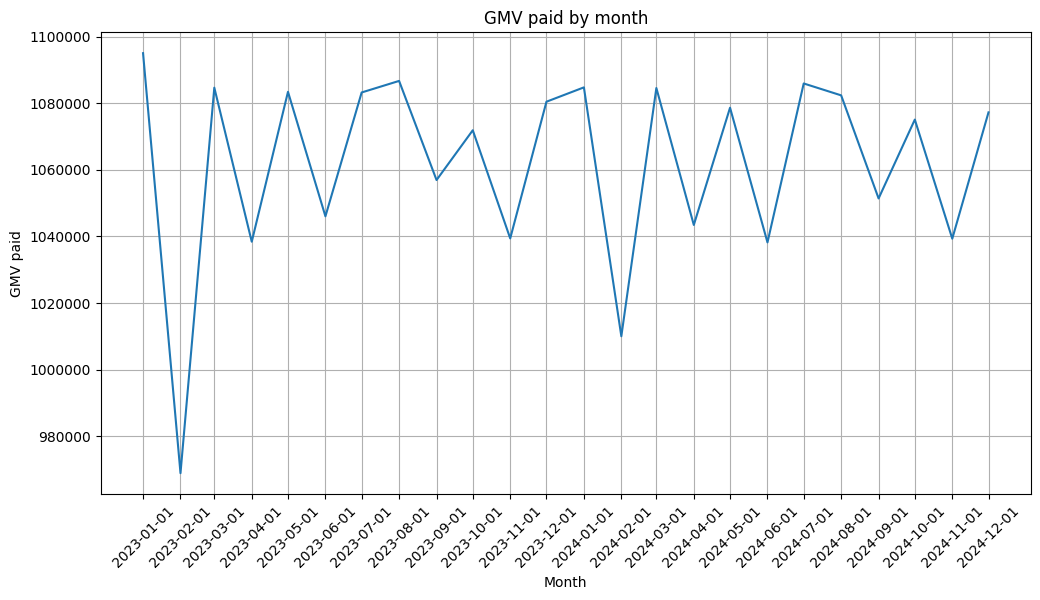

In [55]:
plt.figure(figsize = (12, 6))
plt.plot(df_month.month_order,
            df_month.gmv)

plt.ticklabel_format(axis='y', style='plain')
plt.xticks(df_month.month_order.unique(),
           rotation = 45)

plt.title('GMV paid by month')
plt.xlabel('Month')
plt.ylabel('GMV paid')

plt.grid()
plt.show()